# Preprocess imaging data

## Import libraries

In [1]:
from pathlib import Path
import os.path
from datetime import datetime
import pickle
import matplotlib.pyplot as plt
import numpy as np
import warnings

from unityvr.preproc import logproc as lp
from unityvr.analysis import posAnalysis
from gulp2p.preproc import utils as utils
from gulp2p.preproc import imaging
from gulp2p.preproc import rois
from gulp2p.viz import plotting

## Get tiffs for a given set of experiments

In [2]:
file_names = utils.load_file_names()
print(file_names)

('Z:/2PImaging/Kerstin/MIMS/20240117/20240117_DR019xiGluSnFr_Fly1_00004.tif',)


## Preprocess data

In [3]:
# trial_tiff_path = Path(r'z:\2PImaging\Kerstin\MIMS\20231129\20231129_DR018xiGluSnFr_Fly2_00001.tif')
# bhv_data_folder = Path(r'Z:\FlyVR\FlyVR data\Kerstin\20231129')
# bhv_path = utils.get_bhv_path(trial_tiff_path, bhv_data_folder)

In [4]:
# bhv_data_folder = Path(r'Z:\FlyVR\FlyVR data\Kerstin')
# img_data_folder = Path(r"Z:\2PImaging\Kerstin\MIMS\20231129")
# trial_tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20231204\20231204_DR019xEF024_Fly1_00001.tif")

# for file in img_data_folder.rglob('*'):
#     if file.is_file() and (file.suffix == ".tif"):
#         bhv_path = utils.get_bhv_path(file, bhv_data_folder,
#                                 max_creation_delay=720, min_file_mb=5)

In [5]:
# bhv_path = Path(r"Z:\FlyVR\FlyVR data\Kerstin\20231129\Log_2023-11-29_13-45-03.json")
# uvr = lp.constructUnityVRexperiment(str(bhv_path.parent), bhv_path.name)

# length = uvr.posDf.iloc[-1]['time']
# print(f"trial took {length:.3f} seconds to run ({length//60:.0f} minutes and {length%60:.3f} seconds)")


### For each tif:
1. Create motion corrected MIPs
2. Specify the ROIs
3. Calculate the DF/F

### Specify parameters for motion correction

In [6]:
numRefImg = 50 # the number of images to average for the reference image
upsampleFactor = 20 # how much to upsample the image in order to shift the image by less than one pixel
sigma = 2 # the sigma to use in Gaussian filtering

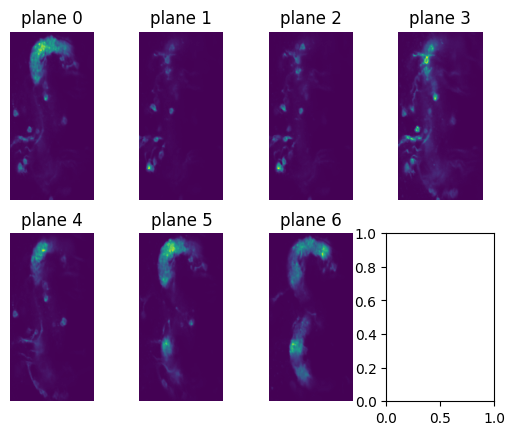

KeyboardInterrupt: 

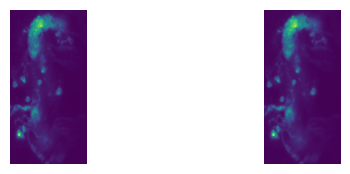

: 

In [7]:
old_rois=None
for i,file in enumerate(file_names):
    exptDat = imaging.preprocess(file, old_rois=old_rois, numRefImg=numRefImg, upsampleFactor=upsampleFactor, sigma=sigma)
    old_rois = exptDat['rois']

NameError: name 'iPP' is not defined

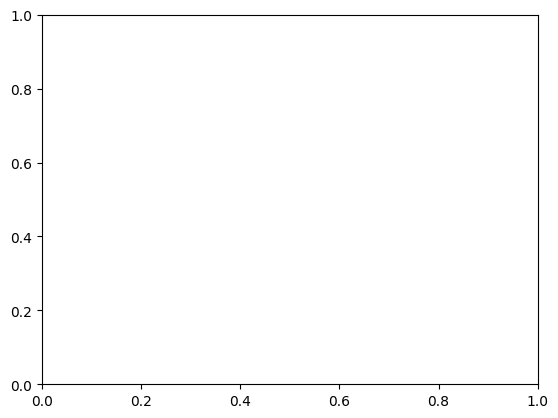

In [ ]:
ax = plt.subplot()
plotting.plot_roi(exptDat, ax, title="")

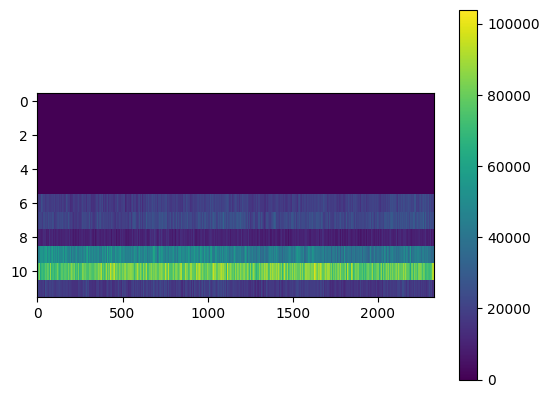

In [ ]:
fig,ax = plt.subplots()
act = ax.imshow(exptDat['rawf'].T, aspect = 100, interpolation="none")
fig.colorbar(act)
# plt.savefig(fig, dpi = 300, format ='svg')

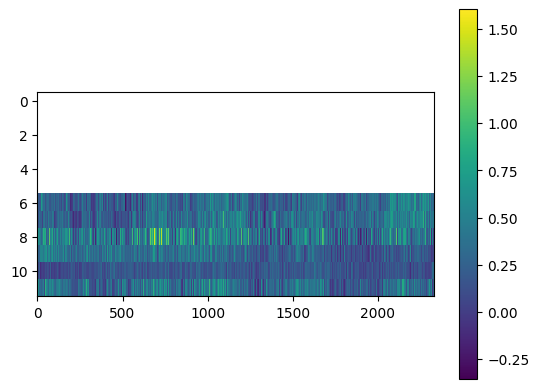

In [ ]:
fig,ax = plt.subplots()
act = ax.imshow(exptDat['deltaf'].T, aspect = 100, interpolation="none")
fig.colorbar(act)

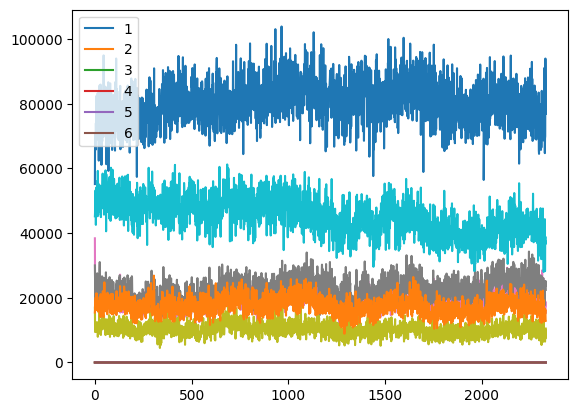

In [ ]:
fig,ax = plt.subplots()
ax.plot(np.arange(0,len(exptDat['rawf'])),exptDat['rawf'])
ax.legend(labels = '123456')
